ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project

In this project, you will use K-Means clustering to segment [credit card customers](https://www.kaggle.com/datasets/arjunbhasin2013/ccdata/data) based on their usage behavior. This is an unsupervised learning problem because the dataset does not contain a target label for customer groups.

You will use the `CC_GENERAL.csv` dataset.

## About the Dataset

The dataset contains customer-level credit card usage behavior. Each row represents one credit card holder, and the columns describe different behavioral variables such as balance, purchases, cash advance, payments, and tenure. The goal is to group similar customers together so that the company can understand different customer segments and design better marketing strategies.

## Import Libraries

**Import the libraries you need for data analysis, visualization, preprocessing, clustering, and evaluation.**

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Get the Data

**Read the `CC_GENERAL.csv` file and save it in a dataframe called `df`.**

In [30]:
df = pd.read_csv('CC_GENERAL.csv')

**Check the first five rows of the dataset.**

In [31]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


**Check the shape of the dataset.**

In [32]:
df.shape

(8950, 18)

**Check basic information about the dataset using `info()`.**

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

**Check summary statistics using `describe()`.**

In [34]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


## Data Cleaning

The column `CUST_ID` is an identification column. It is not useful for clustering because it does not describe customer behavior.

**Drop the `CUST_ID` column from the dataframe.**

In [35]:
df = df.drop('CUST_ID', axis=1)

**Check the missing values in each column.**

In [36]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


Some columns may contain missing values.

Hint: You can handle missing values by either:
- filling them with the mean value
- or dropping the rows that contain missing values

For this project, use mean imputation.

**Fill the missing values with the mean of each column.**

In [37]:
df = df.fillna(df.mean())

**Check the missing values again to make sure they were handled.**

In [38]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


## Exploratory Data Analysis

Before applying clustering, it is important to understand the data.

**Create histograms for the numerical columns.**

array([[<Axes: title={'center': 'BALANCE'}>,
        <Axes: title={'center': 'BALANCE_FREQUENCY'}>,
        <Axes: title={'center': 'PURCHASES'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES'}>],
       [<Axes: title={'center': 'INSTALLMENTS_PURCHASES'}>,
        <Axes: title={'center': 'CASH_ADVANCE'}>,
        <Axes: title={'center': 'PURCHASES_FREQUENCY'}>,
        <Axes: title={'center': 'ONEOFF_PURCHASES_FREQUENCY'}>],
       [<Axes: title={'center': 'PURCHASES_INSTALLMENTS_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_FREQUENCY'}>,
        <Axes: title={'center': 'CASH_ADVANCE_TRX'}>,
        <Axes: title={'center': 'PURCHASES_TRX'}>],
       [<Axes: title={'center': 'CREDIT_LIMIT'}>,
        <Axes: title={'center': 'PAYMENTS'}>,
        <Axes: title={'center': 'MINIMUM_PAYMENTS'}>,
        <Axes: title={'center': 'PRC_FULL_PAYMENT'}>],
       [<Axes: title={'center': 'TENURE'}>, <Axes: >, <Axes: >, <Axes: >]],
      dtype=object)

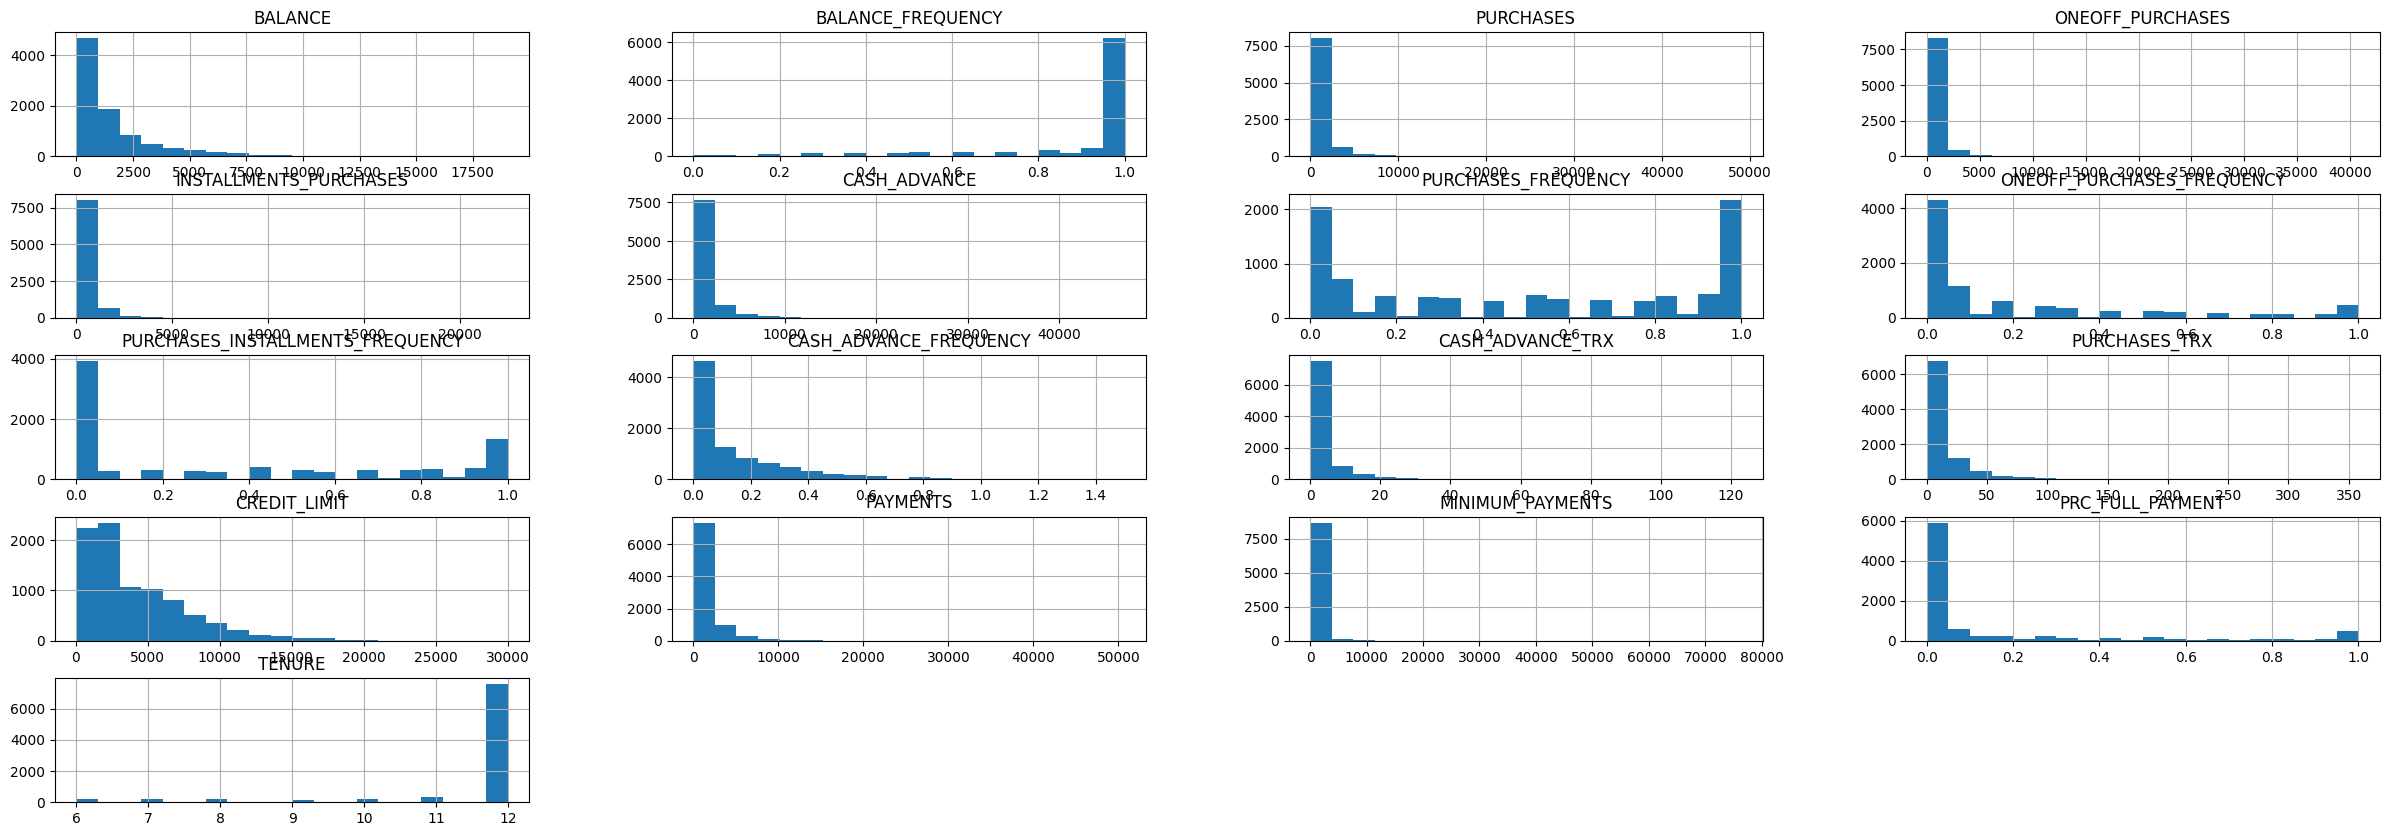

In [39]:
df.hist(figsize=(30,10), bins=20)

**Create a correlation heatmap to understand relationships between the features.**

<Axes: >

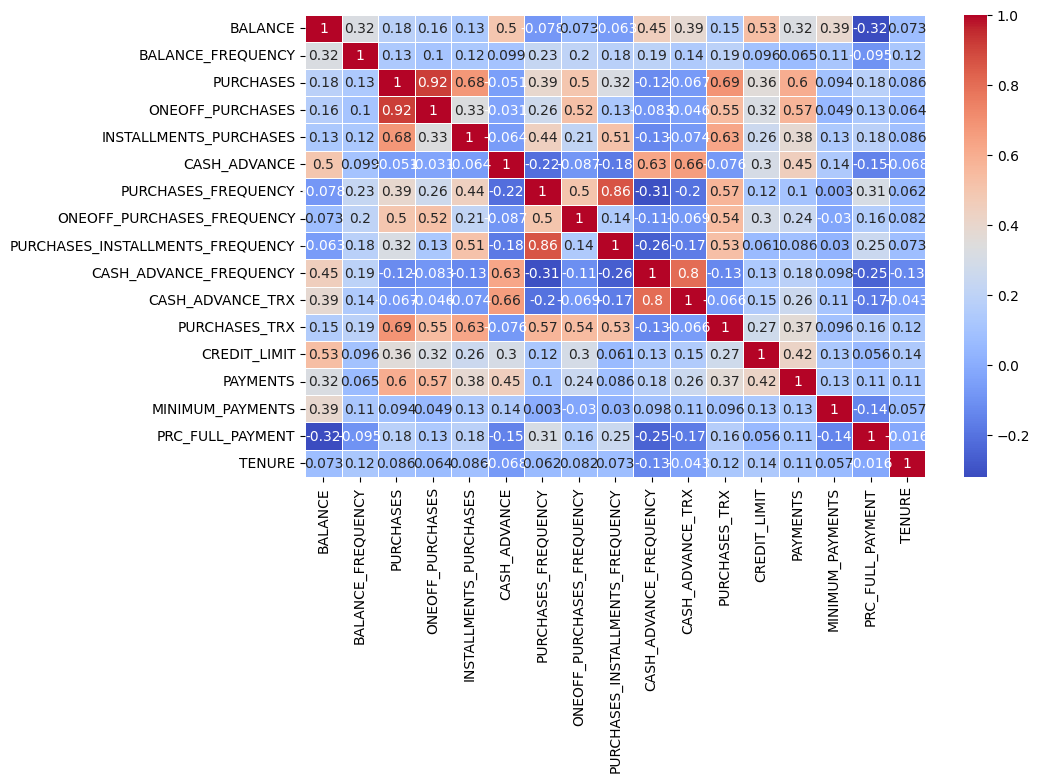

In [40]:

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

**Create a scatter plot between `BALANCE` and `PURCHASES`.**

<Axes: xlabel='BALANCE', ylabel='PURCHASES'>

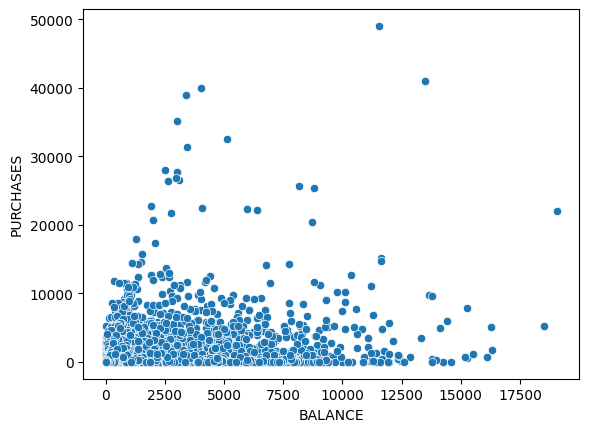

In [41]:
sns.scatterplot( data=df, x="BALANCE", y="PURCHASES" )

**Create a scatter plot between `BALANCE` and `CASH_ADVANCE`.**

<Axes: xlabel='BALANCE', ylabel='CASH_ADVANCE'>

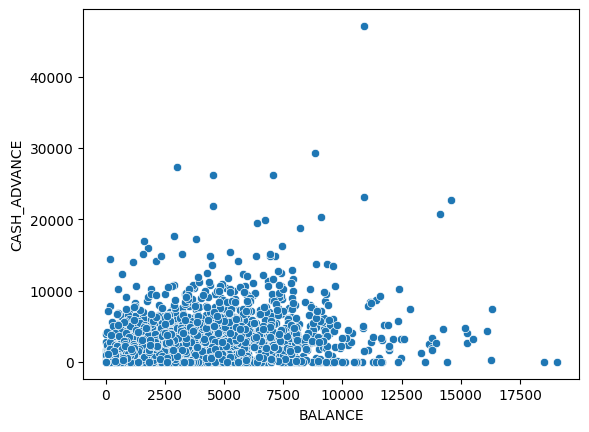

In [42]:
sns.scatterplot( data=df, x="BALANCE", y="CASH_ADVANCE" )

## Feature Scaling

K-Means is a distance-based algorithm. Therefore, feature scaling is very important.

The features in this dataset have very different ranges. For example, `BALANCE`, `PURCHASES`, and `CREDIT_LIMIT` may have large values, while frequency columns are between 0 and 1.

**Use StandardScaler to scale the data. Save the scaled data in a variable called `X_scaled`.**

In [43]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['BALANCE', 'PURCHASES', 'CREDIT_LIMIT']])

X_scaled[0:1]

array([[-0.73198937, -0.42489974, -0.96043334]])

## Choosing K Intuitively

Choosing K is one of the most difficult parts of K-Means.

Since this dataset has many features, it is not easy to visually see the clusters directly.

However, we can still compare different K values using the elbow method and silhouette score.

## Elbow Method

**Create a loop that fits K-Means models for K values from 1 to 10. Save the inertia values in a list called `inertia_values`.**

In [44]:
inertia_values=[]
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df)
    inertia_values.append(kmeans.inertia_)

**Plot the elbow curve.**

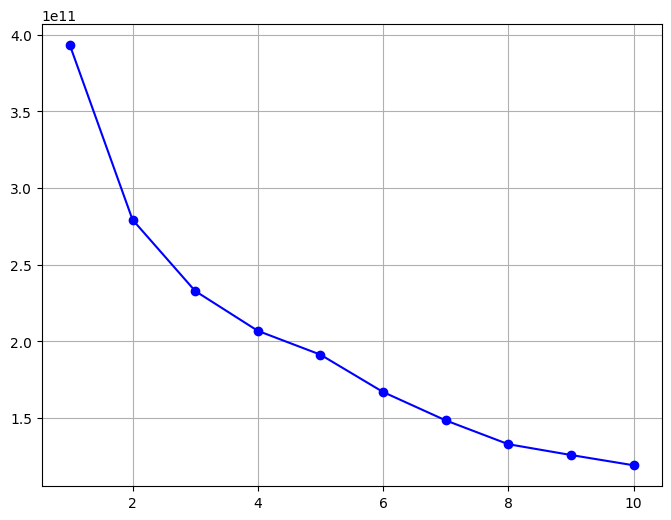

In [45]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia_values, marker='o', linestyle='-', color='blue')
plt.grid(True)
plt.show()

**Output Interpretation**

Look at the elbow curve and try to identify where the decrease in inertia starts to slow down.

That point can suggest a reasonable value for K.

***Notice that it starts to slow down in K=4***

## Silhouette Score

The silhouette score helps evaluate how well-separated the clusters are.

**Create a loop that calculates the silhouette score for K values from 2 to 10. Save the scores in a list called `silhouette_scores`.**

In [46]:
silhouette_scores=[]
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df)
    score = silhouette_score(df, labels)
    silhouette_scores.append(score)

**Plot the silhouette scores.**

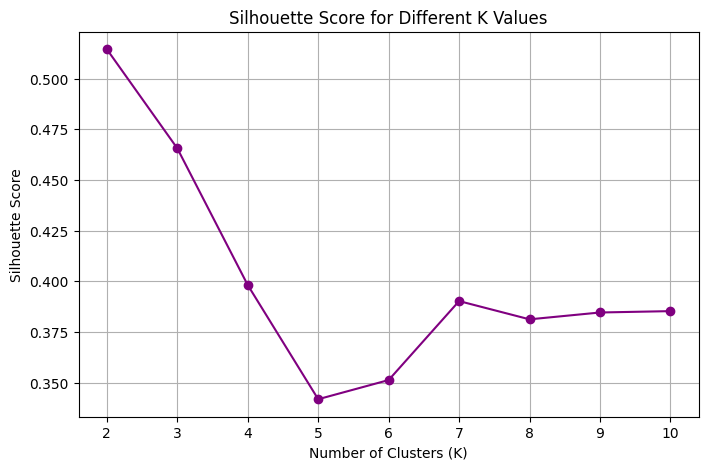

In [47]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='-', color='purple')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")
plt.grid(True)
plt.show()

**Create a table showing each K value and its silhouette score.**

In [48]:
score_table = pd.DataFrame({
    'K': list(range(2, 11)),
    'Silhouette Score': silhouette_scores
})

score_table

,K,Silhouette Score
0,2,0.514503
1,3,0.465607
2,4,0.398138
3,5,0.341810
4,6,0.351269
5,7,0.390230
6,8,0.381227
7,9,0.384605
8,10,0.385276


**Output Interpretation**

A higher silhouette score usually means better clustering.

However, do not rely only on the highest value. Also consider whether the chosen K makes sense for customer segmentation.

## Create the Final K-Means Model

**Based on the elbow curve and silhouette scores, choose a final K value. Then train a final K-Means model.**

Use `random_state=42` and `n_init=10`.

In [49]:
final_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
final_kmeans.fit(df)

KMeans(n_clusters=4, n_init=10, random_state=42)

**Add the final cluster labels to the original dataframe in a new column called `Cluster`.**

In [50]:
 df["Cluster"] = final_kmeans.labels_

**Check the first five rows after adding the cluster labels.**

In [51]:
 df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,864.206542,0.000000,12,2
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,0


## Cluster Analysis

Now we need to understand what each cluster means.

**Create a summary table using `groupby()` to show the mean values of each feature for each cluster.**

In [52]:
cluster_summary = df.groupby("Cluster").mean()
cluster_summary

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,855.190309,0.853211,598.776735,309.660702,289.418153,494.806311,0.466150,0.152448,0.351838,0.107096,2.257984,10.601705,2710.925277,992.123429,553.855905,0.155986,11.428682
1,4748.991790,0.907786,10465.636391,7440.024662,3025.777143,5409.993897,0.735407,0.585386,0.589869,0.229576,9.195489,83.473684,12481.578947,18066.318410,2349.030588,0.329257,11.842105
2,3299.832167,0.940392,1580.265663,991.446909,589.126161,2066.004242,0.543231,0.321592,0.384729,0.208183,5.657793,22.034350,8974.518912,2854.198805,1206.570477,0.139907,11.737656
3,4451.241783,0.985646,1163.288158,168.416053,994.872105,1003.754842,0.499402,0.049043,0.470295,0.088915,2.973684,22.421053,4688.157895,1636.631386,27361.954131,0.000000,11.921053


**Check how many customers are in each cluster.**

In [53]:
df["Cluster"].value_counts()

,count
Cluster,
0,6450
2,2329
1,133
3,38


## Visualizing the Final Clusters

Since the dataset has many features, we will use PCA to reduce the data into two components only for visualization.

This visualization does not replace the original clustering. It only helps us see the clusters in a 2D plot.

**Use PCA with 2 components and plot the clusters.**

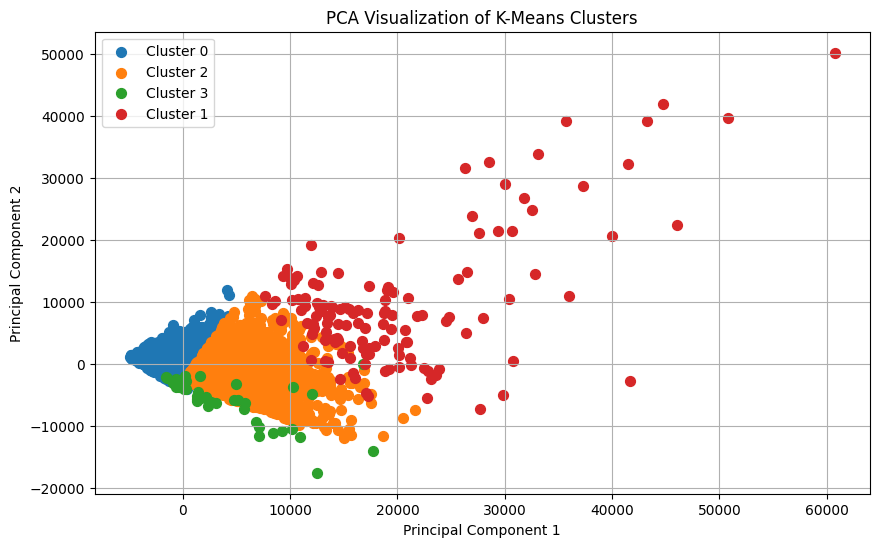

In [54]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(df.drop("Cluster", axis=1))
pca_df = pd.DataFrame(data=pca_components, columns=["PC1", "PC2"])
pca_df["Cluster"] = df["Cluster"]
plt.figure(figsize=(10, 6))
for cluster in pca_df["Cluster"].unique():
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}", s=50)

plt.title("PCA Visualization of K-Means Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

**Output Interpretation**

The PCA plot gives a simplified 2D view of the clusters.

If the clusters are not perfectly separated, that is normal because the original dataset has many features and the plot only shows two compressed dimensions.

## Final Questions

Answer the following questions:

1. Why is this an unsupervised learning problem?
**Because there is no labeled data**

2. Why did we remove the `CUST_ID` column?
**Because the CUST_ID is not a ststical column and is only for identification, leaving it will leave randomness**

3. Which columns had missing values?
**MINIMUM_PAYMENTS, and one CREDIT_LIMIT**

4. How did you handle the missing values?
**Mean imputation**

5. Why is scaling important before applying K-Means?
**Because K-Means is a Destance-Based Algorithm and no scaling will affect the computations**

6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.
**I choose K=4, in the elbow method when K reached 4 it started to slowdown. Meanwhile, in Silhouette Score when K was 4 it was the highest value**

7. Based on the cluster summary table, describe each customer segment in your own words.
**Cluster 0 are the normal customers, they spend moderate and have a normal behavior**
**Cluster 1 are the Customer with High Value they spend a lot and the get big purchase**
**Cluster 2 are customers that are active but not as cluster 1 they spend more than others but not more than cluster 1**
**Cluster 3 they have a high balance but low purchase**

8. Which cluster may represent high-value customers?
**Cluster 1**

9. Which cluster may represent customers who rely more on cash advance?
**Cluster 3**

10. How can a company use these clusters for marketing strategy?
**Cluster 0 --> cashback offers**
**Cluster 1--> loyalty program**
**Cluster 2 --> reward point for every purchase**
**Cluster 3 --> provide safer credit products**


1.
The dataset has no target labels; we aim to find natural groupings without predefined categories.

2.
It is an identifier, not a behavioral feature. Including it would add noise and distort clustering based on non‑patterns.

3.
CREDITLIMIT (1 missing) and MINIMUMPAYMENTS (313 missing).

4.
Filled each column with its mean (mean imputation).

5.
K‑Means uses Euclidean distance. Features with larger ranges (e.g., BALANCE vs. PURCHASESFREQUENCY) would otherwise dominate the distance calculation, biasing the clusters.

6.
K=4
- Elbow method: Inertia starts to slow down noticeably at K=4, indicating diminishing returns.
- Silhouette score: The score was highest for K=4 among the tested values, suggesting better cluster separation.

7.
- Cluster 0: Moderate spenders with average balances and purchase frequencies – “normal” customers.
- Cluster 1: High spenders, large purchases, high credit limits – “high‑value” customers.
- Cluster 2: Active users with above‑average purchases but lower than cluster 1 – “frequent but moderate” customers.
- Cluster 3: High balances but low purchase activity, possibly relying on cash advances – “cash‑advance users”.

8. Cluster 1 (highest purchases, large one‑off purchases, high credit limits).

9. Cluster 3 (high balance, low purchases, likely higher cash advance activity).

10.
- Cluster 0: Cashback offers to increase spending.
- Cluster 1: Loyalty programs and premium rewards to retain high‑value customers.
- Cluster 2: Reward points for every purchase to encourage more spending.
- Cluster 3: Safer credit products (e.g., lower cash advance limits) and debt management advice.